In [ ]:
import pandas as pd

# --2 file extracted from zip(brca_metabric) via cbioportal.org
clinical = pd.read_csv("data/data_clinical_patient.txt", sep="\t", comment="#")
samples  = pd.read_csv("data/data_clinical_sample.txt",  sep="\t", comment="#")

print("Clinical shape:", clinical.shape)
print("\nClinical columns:")
print(clinical.columns.tolist())

Clinical shape: (2509, 24)

Clinical columns:
['PATIENT_ID', 'LYMPH_NODES_EXAMINED_POSITIVE', 'NPI', 'CELLULARITY', 'CHEMOTHERAPY', 'COHORT', 'ER_IHC', 'HER2_SNP6', 'HORMONE_THERAPY', 'INFERRED_MENOPAUSAL_STATE', 'SEX', 'INTCLUST', 'AGE_AT_DIAGNOSIS', 'OS_MONTHS', 'OS_STATUS', 'CLAUDIN_SUBTYPE', 'THREEGENE', 'VITAL_STATUS', 'LATERALITY', 'RADIO_THERAPY', 'HISTOLOGICAL_SUBTYPE', 'BREAST_SURGERY', 'RFS_MONTHS', 'RFS_STATUS']


In [3]:
import numpy as np

# ── Subtype distribution ──
print("=== CLAUDIN_SUBTYPE ===")
print(clinical["CLAUDIN_SUBTYPE"].value_counts())

# ── Survival status format ──
print("\n=== OS_STATUS unique values ===")
print(clinical["OS_STATUS"].unique())

print("\n=== RFS_STATUS unique values ===")
print(clinical["RFS_STATUS"].unique())

# ── Missing values in key columns ──
key_cols = ["OS_MONTHS", "OS_STATUS", "RFS_MONTHS", "RFS_STATUS",
            "CLAUDIN_SUBTYPE", "AGE_AT_DIAGNOSIS",
            "LYMPH_NODES_EXAMINED_POSITIVE", "NPI"]

print("\n=== Missing Values ===")
print(clinical[key_cols].isnull().sum())

# ── Basic survival stats ──
print("\n=== OS_MONTHS summary ===")
print(clinical["OS_MONTHS"].describe())

=== CLAUDIN_SUBTYPE ===
CLAUDIN_SUBTYPE
LumA           700
LumB           475
Her2           224
claudin-low    218
Basal          209
Normal         148
NC               6
Name: count, dtype: int64

=== OS_STATUS unique values ===
['0:LIVING' '1:DECEASED' nan]

=== RFS_STATUS unique values ===
['0:Not Recurred' '1:Recurred' nan]

=== Missing Values ===
OS_MONTHS                        528
OS_STATUS                        528
RFS_MONTHS                       121
RFS_STATUS                        21
CLAUDIN_SUBTYPE                  529
AGE_AT_DIAGNOSIS                  11
LYMPH_NODES_EXAMINED_POSITIVE    266
NPI                              222
dtype: int64

=== OS_MONTHS summary ===
count    1981.000000
mean      125.244271
std        76.111772
min         0.000000
25%        60.866667
50%       116.466667
75%       185.133333
max       355.200000
Name: OS_MONTHS, dtype: float64


In [4]:
import pandas as pd
import numpy as np

# ── 1. Keep only subtypes matching our GSE45827 classifier ──
subtype_map = {
    "LumA":  "Luminal A",
    "LumB":  "Luminal B",
    "Her2":  "Her2",
    "Basal": "Basal"
}

df = clinical[clinical["CLAUDIN_SUBTYPE"].isin(subtype_map.keys())].copy()
df["SUBTYPE"] = df["CLAUDIN_SUBTYPE"].map(subtype_map)

# ── 2. Encode OS_STATUS → binary integer ──
df["OS_EVENT"] = df["OS_STATUS"].str[0].astype(float)

# ── 3. Encode RFS_STATUS → binary integer ──
df["RFS_EVENT"] = df["RFS_STATUS"].str[0].astype(float)

# ── 4. Drop rows missing OS data ──
df = df.dropna(subset=["OS_MONTHS", "OS_EVENT"])

# ── 5. Fill or drop key covariate missings ──
df["AGE_AT_DIAGNOSIS"]           = pd.to_numeric(df["AGE_AT_DIAGNOSIS"], errors="coerce")
df["LYMPH_NODES_EXAMINED_POSITIVE"] = pd.to_numeric(df["LYMPH_NODES_EXAMINED_POSITIVE"], errors="coerce")
df["NPI"]                        = pd.to_numeric(df["NPI"], errors="coerce")

# ── 6. Final check ──
print("Final cohort shape:", df.shape)
print("\nSubtype distribution:")
print(df["SUBTYPE"].value_counts())
print("\nOS_EVENT distribution:")
print(df["OS_EVENT"].value_counts())
print("\nMissing in key columns:")
print(df[["OS_MONTHS", "OS_EVENT", "RFS_MONTHS", "RFS_EVENT",
          "AGE_AT_DIAGNOSIS", "LYMPH_NODES_EXAMINED_POSITIVE", "NPI"]].isnull().sum())
print("\nSample rows:")
print(df[["PATIENT_ID", "SUBTYPE", "OS_MONTHS", "OS_EVENT", "AGE_AT_DIAGNOSIS"]].head())

Final cohort shape: (1608, 27)

Subtype distribution:
SUBTYPE
Luminal A    700
Luminal B    475
Her2         224
Basal        209
Name: count, dtype: int64

OS_EVENT distribution:
OS_EVENT
1.0    965
0.0    643
Name: count, dtype: int64

Missing in key columns:
OS_MONTHS                         0
OS_EVENT                          0
RFS_MONTHS                        0
RFS_EVENT                         1
AGE_AT_DIAGNOSIS                  0
LYMPH_NODES_EXAMINED_POSITIVE    49
NPI                               0
dtype: int64

Sample rows:
  PATIENT_ID    SUBTYPE   OS_MONTHS  OS_EVENT  AGE_AT_DIAGNOSIS
1    MB-0002  Luminal A   84.633333       0.0             43.19
2    MB-0005  Luminal B  163.700000       1.0             48.87
3    MB-0006  Luminal B  164.933333       0.0             47.68
4    MB-0008  Luminal B   41.366667       1.0             76.97
5    MB-0010  Luminal B    7.800000       1.0             78.77


In [5]:
#Phase 2: Pull Biomarker Gene Expression via API
import requests
import pandas as pd

BASE  = "https://www.cbioportal.org/api"
STUDY = "brca_metabric"

# ── Step 1: Confirm the expression profile ID ──
print("=== MOLECULAR PROFILES ===")
profiles = requests.get(f"{BASE}/studies/{STUDY}/molecular-profiles").json()
for p in profiles:
    print(p["molecularProfileId"], "→", p["name"])

=== MOLECULAR PROFILES ===
brca_metabric_cna → Putative copy-number alterations from DNAcopy.
brca_metabric_methylation_promoters_rrbs → Promoter methylation (RRBS)
brca_metabric_mrna → mRNA expression (Illumina HT-12 v3 microarray)
brca_metabric_mrna_median_all_sample_Zscores → mRNA expression z-scores relative to all samples (log microarray)
brca_metabric_mutations → Mutations


In [6]:
import requests
import pandas as pd

BASE     = "https://www.cbioportal.org/api"
STUDY    = "brca_metabric"
PROFILE  = "brca_metabric_mrna_median_all_sample_Zscores"

# ── Your biomarker genes from the GSE45827 project ──
# Paste your full gene_symbols list from the previous notebook here
biomarker_genes = [
'PTTG1', 'KIF14', 'ASPM', 'CENPE', 'MLPH', 'CACYBP', 'STARD10', 'EZH2',
 'ERBB2', 'WFS1', 'AURKA', 'CENPA', 'SLC35F6', 'CDCA3', 'CCNB2', 'MND1',
 'UBE2T', 'NME3', 'SUV39H2', 'GRB7', 'AGR2', 'CDCA5', 'CEP126', 'MYBL2',
 'CDC6', 'SPDEF', 'SPAG5', 'BUB1', 'IL6ST', 'ESR1', 'GATA3', 'SMIM13', 'AURKB',
 'EME2', 'GABRP', 'BTG3', 'CFAP69', 'CMC2', 'GPN1', 'FOXM1', 'ZNF740', 'ABAT',
 'LRRC37A2', 'LRRC37A4P', 'SRSF5', 'CA12']
    #actual full list from gene_symbols variable


# ── Step 1: Convert gene symbols → Entrez IDs ──
gene_resp = requests.post(
    f"{BASE}/genes/fetch?geneIdType=HUGO_GENE_SYMBOL",
    json=biomarker_genes
).json()

entrez_ids  = [g["entrezGeneId"] for g in gene_resp]
found_genes = [g["hugoGeneSymbol"] for g in gene_resp]
print(f"Genes requested: {len(biomarker_genes)}")
print(f"Genes found in cBioPortal: {len(found_genes)}")
print("Found:", found_genes)

# ── Step 2: Get all sample IDs for METABRIC ──
samples_resp = requests.get(
    f"{BASE}/studies/{STUDY}/samples?projection=ID"
).json()
all_sample_ids = [s["sampleId"] for s in samples_resp]
print(f"\nTotal METABRIC samples: {len(all_sample_ids)}")

# ── Step 3: Filter to only our 1,608 clean cohort patients ──
# METABRIC sample IDs match patient IDs directly (MB-XXXX)
cohort_patient_ids = set(df["PATIENT_ID"].tolist())
cohort_sample_ids  = [s for s in all_sample_ids if s in cohort_patient_ids]
print(f"Cohort sample IDs matched: {len(cohort_sample_ids)}")

# ── Step 4: Fetch expression values ──
payload = {
    "entrezGeneIds": entrez_ids,
    "sampleIds":     cohort_sample_ids
}
expr_resp = requests.post(
    f"{BASE}/molecular-profiles/{PROFILE}/molecular-data/fetch?projection=SUMMARY",
    json=payload
).json()

expr_df = pd.DataFrame(expr_resp)
print(f"\nExpression data shape (long format): {expr_df.shape}")
print(expr_df.head())

Genes requested: 46
Genes found in cBioPortal: 46
Found: ['ABAT', 'AGR2', 'ASPM', 'AURKA', 'AURKB', 'BTG3', 'BUB1', 'CA12', 'CACYBP', 'CCNB2', 'CDC6', 'CDCA3', 'CDCA5', 'CENPA', 'CENPE', 'CEP126', 'CFAP69', 'CMC2', 'EME2', 'ERBB2', 'ESR1', 'EZH2', 'FOXM1', 'GABRP', 'GATA3', 'GPN1', 'GRB7', 'IL6ST', 'KIF14', 'LRRC37A2', 'LRRC37A4P', 'MLPH', 'MND1', 'MYBL2', 'NME3', 'PTTG1', 'SLC35F6', 'SMIM13', 'SPAG5', 'SPDEF', 'SRSF5', 'STARD10', 'SUV39H2', 'UBE2T', 'WFS1', 'ZNF740']

Total METABRIC samples: 2509
Cohort sample IDs matched: 1608

Expression data shape (long format): (73968, 8)
                uniqueSampleKey              uniquePatientKey  entrezGeneId  \
0  TUItMDAwMjpicmNhX21ldGFicmlj  TUItMDAwMjpicmNhX21ldGFicmlj            18   
1  TUItMDAwMjpicmNhX21ldGFicmlj  TUItMDAwMjpicmNhX21ldGFicmlj         10551   
2  TUItMDAwMjpicmNhX21ldGFicmlj  TUItMDAwMjpicmNhX21ldGFicmlj          2146   
3  TUItMDAwMjpicmNhX21ldGFicmlj  TUItMDAwMjpicmNhX21ldGFicmlj          2305   
4  TUItMDAwMjpicmNhX2

In [7]:
# ── Step 5: Pivot long-format expression → wide (patients × Entrez genes) ──
id_col = "patientId" if "patientId" in expr_df.columns else "sampleId"

expr_wide = (
    expr_df
    .pivot_table(index=id_col,
                 columns="entrezGeneId",
                 values="value",
                 aggfunc="first")
    .reset_index()
    .rename(columns={id_col: "PATIENT_ID"})
)

expr_wide["PATIENT_ID"] = expr_wide["PATIENT_ID"].astype(str).str.replace(r"-\d+$", "", regex=True)
expr_wide.columns = [str(c) for c in expr_wide.columns]

print(f"expr_wide shape (wide format): {expr_wide.shape}")
print("Sample columns:", expr_wide.columns.tolist()[:8])

expr_wide shape (wide format): (1608, 47)
Sample columns: ['PATIENT_ID', '18', '699', '771', '990', '1058', '1062', '2064']


In [8]:
import pandas as pd

# ── Rebuild expr_wide FRESH from expr_df (ignore any prior in-memory version) ──
id_col = "patientId" if "patientId" in expr_df.columns else "sampleId"
expr_wide = (
    expr_df
    .pivot_table(index=id_col, columns="entrezGeneId", values="value", aggfunc="first")
    .reset_index()
    .rename(columns={id_col: "PATIENT_ID"})
)
expr_wide.columns = [str(c) for c in expr_wide.columns]   # Entrez IDs → str; NO stripping

# ── Entrez ID → Gene Symbol rename ──
entrez_to_symbol = {g["entrezGeneId"]: g["hugoGeneSymbol"] for g in gene_resp}
expr_wide_named = expr_wide.copy()
expr_wide_named.columns = [
    entrez_to_symbol.get(int(c), c) if str(c).isdigit() else c
    for c in expr_wide_named.columns
]

# ── Normalize BOTH keys, then show them so we can see any mismatch ──
df["PATIENT_ID"] = df["PATIENT_ID"].astype(str).str.strip()
expr_wide_named["PATIENT_ID"] = expr_wide_named["PATIENT_ID"].astype(str).str.strip()
print("df ids   :", df["PATIENT_ID"].head(3).tolist())
print("expr ids :", expr_wide_named["PATIENT_ID"].head(3).tolist())
print("overlap  :", len(set(df["PATIENT_ID"]) & set(expr_wide_named["PATIENT_ID"])))

# ── Merge + clean ──
merged = df.merge(expr_wide_named, on="PATIENT_ID", how="inner")
gene_cols = [c for c in merged.columns if c in found_genes]
merged_clean = merged.dropna(subset=gene_cols).copy()
merged_clean["OS_MONTHS"] = pd.to_numeric(merged_clean["OS_MONTHS"], errors="coerce")
merged_clean["OS_EVENT"]  = pd.to_numeric(merged_clean["OS_EVENT"],  errors="coerce")
merged_clean = merged_clean.dropna(subset=["OS_MONTHS", "OS_EVENT"])
merged_clean["OS_EVENT"] = merged_clean["OS_EVENT"].astype(int)

print("\nSUBTYPE values:", merged_clean["SUBTYPE"].unique().tolist())
print(f"Final cohort: {merged_clean.shape} | events: {merged_clean['OS_EVENT'].sum():.0f}")
merged_clean.to_csv("metabric_survival_analysis.csv", index=False)
print("✅ Saved")

df ids   : ['MB-0002', 'MB-0005', 'MB-0006']
expr ids : ['MB-0002', 'MB-0005', 'MB-0006']
overlap  : 1608

SUBTYPE values: ['Luminal A', 'Luminal B', 'Her2', 'Basal']
Final cohort: (1608, 73) | events: 965
✅ Saved


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.2 MB/s eta 0:00:00
Subtype column used: 'SUBTYPE'
Rows: 1608 -> 1608 after cleaning
Subtype counts:
 SUBTYPE_CLEAN
Luminal A    700
Luminal B    475
HER2         224
Basal        209
Name: count, dtype: int64 



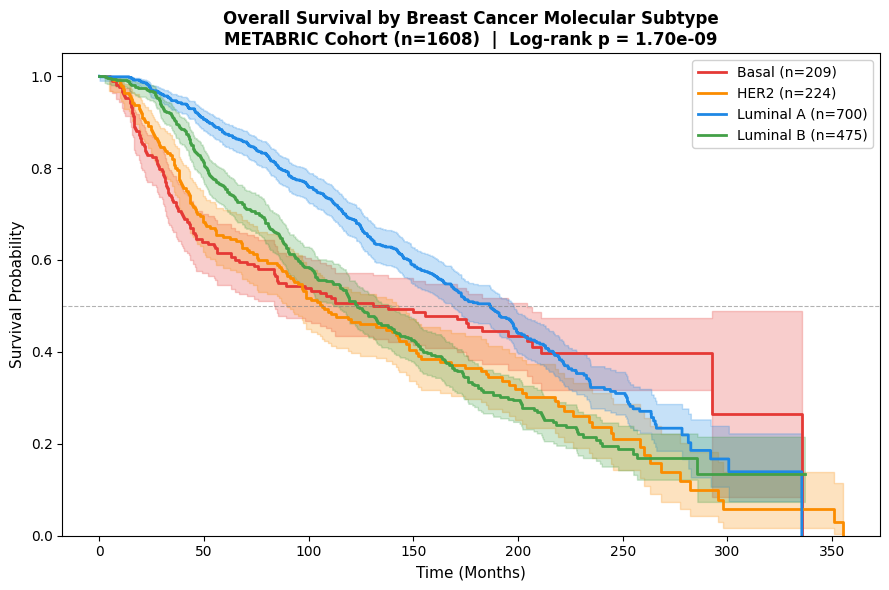


Log-rank test p-value: 1.70e-09
Test statistic: 43.7518


In [9]:
# Phase 3: Kaplan-Meier Survival Curves
!pip install lifelines --quiet

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── 1. Get the data: use merged_clean if usable, else the saved checkpoint CSV ──
df_km = merged_clean.copy() if "merged_clean" in dir() and len(merged_clean) > 0 else pd.DataFrame()
if len(df_km) == 0:
    print("merged_clean empty → loading metabric_survival_analysis.csv checkpoint")
    df_km = pd.read_csv("metabric_survival_analysis.csv")

# ── 2. OS_EVENT: derive from OS_STATUS if missing, force numeric ──
if "OS_EVENT" not in df_km.columns or df_km["OS_EVENT"].isna().all():
    df_km["OS_EVENT"] = df_km["OS_STATUS"].astype(str).str.startswith("1").astype(int)
df_km["OS_EVENT"]  = pd.to_numeric(df_km["OS_EVENT"], errors="coerce")
df_km["OS_MONTHS"] = pd.to_numeric(df_km["OS_MONTHS"], errors="coerce")

# ── 3. Normalize subtype labels (handles SUBTYPE or CLAUDIN_SUBTYPE) ──
sub_col = "SUBTYPE" if "SUBTYPE" in df_km.columns else "CLAUDIN_SUBTYPE"
label_map = {
    "LumA": "Luminal A", "Luminal A": "Luminal A",
    "LumB": "Luminal B", "Luminal B": "Luminal B",
    "Her2": "HER2", "HER2": "HER2",
    "Basal": "Basal",
}
df_km["SUBTYPE_CLEAN"] = df_km[sub_col].astype(str).str.strip().map(label_map)

# ── 4. Clean ──
before = len(df_km)
df_km = df_km.dropna(subset=["OS_MONTHS", "OS_EVENT", "SUBTYPE_CLEAN"])
df_km["OS_EVENT"] = df_km["OS_EVENT"].astype(int)
print(f"Subtype column used: '{sub_col}'")
print(f"Rows: {before} -> {len(df_km)} after cleaning")
print("Subtype counts:\n", df_km["SUBTYPE_CLEAN"].value_counts(), "\n")

# ── 5. Kaplan-Meier plot ──
palette = {"Basal": "#E53935", "HER2": "#FB8C00",
           "Luminal A": "#1E88E5", "Luminal B": "#43A047"}

fig, ax = plt.subplots(figsize=(9, 6))
kmf = KaplanMeierFitter()
for subtype, color in palette.items():
    mask = df_km["SUBTYPE_CLEAN"] == subtype
    if mask.sum() == 0:
        print(f"⚠ no rows for subtype '{subtype}'")
        continue
    kmf.fit(df_km.loc[mask, "OS_MONTHS"], df_km.loc[mask, "OS_EVENT"],
            label=f"{subtype} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True, linewidth=2)

# ── 6. Log-rank test (only if ≥2 subtypes have data) ──
if df_km["SUBTYPE_CLEAN"].nunique() >= 2:
    logrank = multivariate_logrank_test(
        df_km["OS_MONTHS"], df_km["SUBTYPE_CLEAN"], df_km["OS_EVENT"])
    p_txt = f"Log-rank p = {logrank.p_value:.2e}"
else:
    logrank = None
    p_txt = "Log-rank: not enough groups"

ax.set_title(
    f"Overall Survival by Breast Cancer Molecular Subtype\n"
    f"METABRIC Cohort (n={len(df_km)})  |  {p_txt}",
    fontsize=12, fontweight="bold")
ax.set_xlabel("Time (Months)", fontsize=11)
ax.set_ylabel("Survival Probability", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=10, framealpha=0.9)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig("KM_survival_by_subtype.png", dpi=300, bbox_inches="tight")
plt.show()

if logrank is not None:
    print(f"\nLog-rank test p-value: {logrank.p_value:.2e}")
    print(f"Test statistic: {logrank.test_statistic:.4f}")

In [10]:
#Multivariate Cox Regression
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Encode subtype as dummy variables (Luminal A as reference) ──
cox_df = merged_clean.copy()
cox_df = pd.get_dummies(cox_df, columns=["SUBTYPE"], drop_first=False)
cox_df = cox_df.drop(columns=["SUBTYPE_Luminal A"])  # reference category

# ── Select Cox input columns ──
clinical_covariates = [
    "AGE_AT_DIAGNOSIS",
    "LYMPH_NODES_EXAMINED_POSITIVE",
    "NPI",
    "SUBTYPE_Basal",
    "SUBTYPE_Her2",
    "SUBTYPE_Luminal B"
]

# Fill remaining missing in lymph nodes with median
cox_df["LYMPH_NODES_EXAMINED_POSITIVE"] = cox_df["LYMPH_NODES_EXAMINED_POSITIVE"].fillna(
    cox_df["LYMPH_NODES_EXAMINED_POSITIVE"].median()
)

# ── Model 1: Clinical only (baseline) ──
cols_clinical = clinical_covariates + ["OS_MONTHS", "OS_EVENT"]
cph_clinical = CoxPHFitter(penalizer=0.1)
cph_clinical.fit(
    cox_df[cols_clinical],
    duration_col="OS_MONTHS",
    event_col="OS_EVENT"
)
print("=== MODEL 1: Clinical Variables Only ===")
cph_clinical.print_summary(decimals=4)
print(f"Concordance Index: {cph_clinical.concordance_index_:.4f}")

# ── Model 2: Clinical + Biomarker Genes ──
cols_full = clinical_covariates + gene_cols + ["OS_MONTHS", "OS_EVENT"]
cph_full = CoxPHFitter(penalizer=0.1)
cph_full.fit(
    cox_df[cols_full],
    duration_col="OS_MONTHS",
    event_col="OS_EVENT"
)
print("\n=== MODEL 2: Clinical + Biomarker Genes ===")
cph_full.print_summary(decimals=4)
print(f"Concordance Index: {cph_full.concordance_index_:.4f}")

# ── Compare C-index improvement ──
print("\n=== MODEL COMPARISON ===")
print(f"Clinical only     C-index: {cph_clinical.concordance_index_:.4f}")
print(f"Clinical + Genes  C-index: {cph_full.concordance_index_:.4f}")
print(f"Improvement:              +{cph_full.concordance_index_ - cph_clinical.concordance_index_:.4f}")

=== MODEL 1: Clinical Variables Only ===


<lifelines.CoxPHFitter: fitted with 1608 total observations, 643 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1608
number of events observed = 965
   partial log-likelihood = -6285.6133
         time fit was run = 2026-07-12 09:51:29 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                       
AGE_AT_DIAGNOSIS              0.0304    1.0309    0.0026          0.0252          0.0356              1.0255              1.0362
LYMPH_NODES_EXAMINED_POSITIVE 0.0409    1.0417    0.0064          0.0283          0.0535              1.0287              1.0550
NPI                           0.1626    1.1766    0.0302          0.1035          0.2218              1.1090              1.2483
SUBTYPE_Basal                 0.2540    1.2892    0.0996          0.0588          0.4492              1.0606              1.5670
SUBTYPE_Her2                  0.3504    1.4196    0.0887          0.1765          0.5242              1.1931              1.6891
SUBTYPE_Luminal B             0.1796    1.1968    0.0695          0.0433          0.3159              1.0443              1.3715

                               cmp to       z      p  -log2(p)
covariate                                                     
AGE_AT_DIAGNOSIS               0.0000 11.5174 <5e-05   99.5498
LYMPH_NODES_EXAMINED_POSITIVE  0.0000  6.3585 <5e-05   32.1926
NPI                            0.0000  5.3860 <5e-05   23.7263
SUBTYPE_Basal                  0.0000  2.5508 0.0107    6.5398
SUBTYPE_Her2                   0.0000  3.9504 0.0001   13.6458
SUBTYPE_Luminal B              0.0000  2.5831 0.0098    6.6741
---
Concordance = 0.6567
Partial AIC = 12583.2266
log-likelihood ratio test = 265.2049 on 6 df
-log2(p) of ll-ratio test = 178.1812

Concordance Index: 0.6567

=== MODEL 2: Clinical + Biomarker Genes ===


<lifelines.CoxPHFitter: fitted with 1608 total observations, 643 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1608
number of events observed = 965
   partial log-likelihood = -6256.6184
         time fit was run = 2026-07-12 09:51:29 UTC

---
                                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                        
AGE_AT_DIAGNOSIS               0.0322    1.0327    0.0028          0.0267          0.0377              1.0270              1.0384
LYMPH_NODES_EXAMINED_POSITIVE  0.0462    1.0473    0.0069          0.0326          0.0598              1.0332              1.0617
NPI                            0.1290    1.1377    0.0316          0.0670          0.1910              1.0693              1.2105
SUBTYPE_Basal                 -0.0294    0.9710    0.1547         -0.3326          0.2738              0.7171              1.3149
SUBTYPE_Her2                   0.1354    1.1450    0.1189         -0.0977          0.3685              0.9069              1.4456
SUBTYPE_Luminal B              0.1198    1.1273    0.0866         -0.0499          0.2896              0.9513              1.3358
ABAT                          -0.0712    0.9313    0.0382         -0.1460          0.0036              0.8642              1.0036
BUB1                           0.0304    1.0309    0.0570         -0.0812          0.1421              0.9220              1.1526
CA12                           0.0150    1.0152    0.0504         -0.0838          0.1139              0.9196              1.1206
CDC6                          -0.0407    0.9602    0.0347         -0.1087          0.0274              0.8970              1.0277
CENPA                         -0.0552    0.9463    0.0609         -0.1746          0.0643              0.8398              1.0664
CENPE                          0.0301    1.0305    0.0527         -0.0732          0.1333              0.9294              1.1426
ERBB2                          0.0054    1.0054    0.0514         -0.0953          0.1061              0.9091              1.1119
ESR1                          -0.0231    0.9771    0.0553         -0.1316          0.0853              0.8767              1.0891
EZH2                          -0.0505    0.9507    0.0449         -0.1385          0.0374              0.8707              1.0381
FOXM1                          0.0344    1.0350    0.0564         -0.0761          0.1449              0.9268              1.1559
GABRP                          0.0764    1.0794    0.0489         -0.0194          0.1722              0.9808              1.1879
GATA3                         -0.0437    0.9572    0.0551         -0.1516          0.0642              0.8593              1.0663
GRB7                           0.0806    1.0840    0.0491         -0.0156          0.1768              0.9846              1.1934
IL6ST                          0.0013    1.0013    0.0436         -0.0842          0.0869              0.9192              1.0908
MYBL2                         -0.0251    0.9752    0.0311         -0.0860          0.0359              0.9176              1.0365
NME3                          -0.0642    0.9378    0.0439         -0.1502          0.0219              0.8605              1.0221
SRSF5                          0.0628    1.0649    0.0357         -0.0071          0.1328              0.9929              1.1420
AURKA                          0.0480    1.0491    0.0525         -0.0550          0.1509              0.9465              1.1629
WFS1                          -0.0345    0.9660    0.0413         -0.1155          0.0464              0.8909              1.0475
CCNB2                         -0.0023    0.9977    0.059

Concordance Index: 0.6788

=== MODEL COMPARISON ===
Clinical only     C-index: 0.6567
Clinical + Genes  C-index: 0.6788
Improvement:              +0.0221


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Extract full Cox results from Model 2 ──
cox_summary = cph_full.summary.copy()
cox_summary.columns = cox_summary.columns.str.strip()
cox_summary = cox_summary.reset_index()
cox_summary.columns.values[0] = "variable"

print("Columns:", cox_summary.columns.tolist())
print(cox_summary.head(3))

Columns: ['variable', 'coef', 'exp(coef)', 'se(coef)', 'coef lower 95%', 'coef upper 95%', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'cmp to', 'z', 'p', '-log2(p)']
                        variable      coef  exp(coef)  se(coef)  \
0               AGE_AT_DIAGNOSIS  0.032175   1.032698  0.002813   
1  LYMPH_NODES_EXAMINED_POSITIVE  0.046241   1.047327  0.006936   
2                            NPI  0.129022   1.137715  0.031645   

   coef lower 95%  coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
0        0.026661        0.037689             1.027019             1.038408   
1        0.032647        0.059835             1.033186             1.061661   
2        0.067000        0.191045             1.069295             1.210513   

   cmp to          z             p   -log2(p)  
0     0.0  11.436260  2.755064e-30  98.195757  
1     0.0   6.667055  2.609879e-11  35.157226  
2     0.0   4.077226  4.557615e-05  14.421361  


In [12]:
# ── Identify significant biomarker genes ──
gene_results = cox_summary[cox_summary["variable"].isin(gene_cols)].copy()
sig_genes = gene_results[gene_results["p"] < 0.05].sort_values("p")

print("=== SIGNIFICANT BIOMARKER GENES (p < 0.05) ===")
print(sig_genes[["variable", "coef", "exp(coef)", "p"]].to_string())

print("\n=== BORDERLINE SIGNIFICANT (p < 0.10) ===")
borderline = gene_results[(gene_results["p"] >= 0.05) & (gene_results["p"] < 0.10)]
print(borderline[["variable", "coef", "exp(coef)", "p"]].to_string())

=== SIGNIFICANT BIOMARKER GENES (p < 0.05) ===
   variable      coef  exp(coef)         p
46    CDCA5  0.134328   1.143768  0.022631
39     CMC2 -0.084352   0.919107  0.049480

=== BORDERLINE SIGNIFICANT (p < 0.10) ===
   variable      coef  exp(coef)         p
6      ABAT -0.071206   0.931270  0.062034
22    SRSF5  0.062836   1.064852  0.078437
29     AGR2  0.075307   1.078215  0.056108
45     MND1 -0.074768   0.927959  0.074560


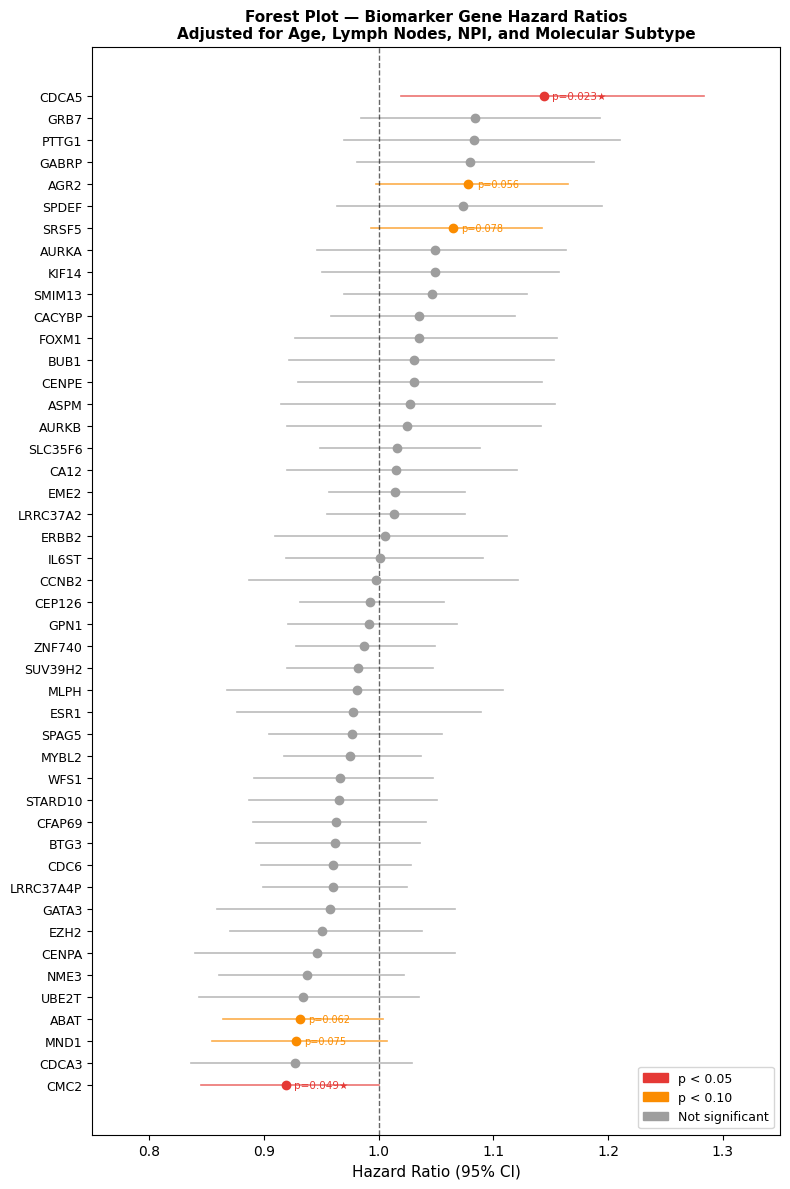

In [13]:
#Figure1-ForestPlot
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Prepare gene-only results ──
forest_df = gene_results.copy().sort_values("coef", ascending=True)

hr     = forest_df["exp(coef)"].values
hr_lo  = forest_df["exp(coef) lower 95%"].values
hr_hi  = forest_df["exp(coef) upper 95%"].values
genes  = forest_df["variable"].values
pvals  = forest_df["p"].values

# ── Colour: red = significant, orange = borderline, grey = NS ──
colors = []
for p in pvals:
    if p < 0.05:
        colors.append("#E53935")
    elif p < 0.10:
        colors.append("#FB8C00")
    else:
        colors.append("#9E9E9E")

fig, ax = plt.subplots(figsize=(8, 12))
y_pos = np.arange(len(genes))

# Error bars (CI)
for i, (h, lo, hi, c) in enumerate(zip(hr, hr_lo, hr_hi, colors)):
    ax.plot([lo, hi], [i, i], color=c, linewidth=1.2, alpha=0.7)
    ax.plot(h, i, "o", color=c, markersize=6, zorder=5)

# Reference line at HR=1
ax.axvline(x=1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)

# Annotations for significant genes
for i, (gene, p, h) in enumerate(zip(genes, pvals, hr)):
    if p < 0.05:
        ax.annotate(f"p={p:.3f}★", xy=(h, i),
                    xytext=(6, 0), textcoords="offset points",
                    fontsize=7.5, color="#E53935", va="center")
    elif p < 0.10:
        ax.annotate(f"p={p:.3f}", xy=(h, i),
                    xytext=(6, 0), textcoords="offset points",
                    fontsize=7, color="#FB8C00", va="center")

ax.set_yticks(y_pos)
ax.set_yticklabels(genes, fontsize=9)
ax.set_xlabel("Hazard Ratio (95% CI)", fontsize=11)
ax.set_title(
    "Forest Plot — Biomarker Gene Hazard Ratios\n"
    "Adjusted for Age, Lymph Nodes, NPI, and Molecular Subtype",
    fontsize=11, fontweight="bold"
)

# Legend
legend_elements = [
    mpatches.Patch(color="#E53935", label="p < 0.05"),
    mpatches.Patch(color="#FB8C00", label="p < 0.10"),
    mpatches.Patch(color="#9E9E9E", label="Not significant"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax.set_xlim(0.75, 1.35)

plt.tight_layout()
plt.savefig("forest_plot_biomarkers.png", dpi=300, bbox_inches="tight")
plt.show()

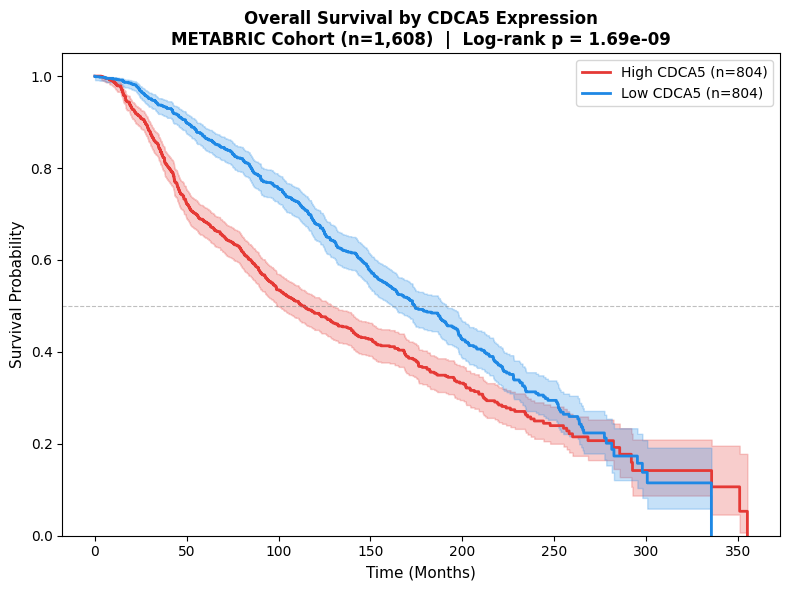

Log-rank p-value: 1.6890e-09
CDCA5 median expression (z-score): 0.0212


In [14]:
#Figure 2: CDCA5 High vs Low Survival
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# ── Split on CDCA5 median expression ──
cdca5_median = merged_clean["CDCA5"].median()
merged_clean["CDCA5_group"] = np.where(
    merged_clean["CDCA5"] >= cdca5_median,
    f"High CDCA5 (n={(merged_clean['CDCA5'] >= cdca5_median).sum()})",
    f"Low CDCA5 (n={(merged_clean['CDCA5'] < cdca5_median).sum()})"
)

high = merged_clean[merged_clean["CDCA5"] >= cdca5_median]
low  = merged_clean[merged_clean["CDCA5"] <  cdca5_median]

# ── Log-rank test ──
lr = logrank_test(
    high["OS_MONTHS"], low["OS_MONTHS"],
    high["OS_EVENT"],  low["OS_EVENT"]
)

# ── Plot ──
fig, ax = plt.subplots(figsize=(8, 6))
kmf = KaplanMeierFitter()

kmf.fit(high["OS_MONTHS"], high["OS_EVENT"],
        label=f"High CDCA5 (n={len(high)})")
kmf.plot_survival_function(ax=ax, color="#E53935", ci_show=True, linewidth=2)

kmf.fit(low["OS_MONTHS"], low["OS_EVENT"],
        label=f"Low CDCA5 (n={len(low)})")
kmf.plot_survival_function(ax=ax, color="#1E88E5", ci_show=True, linewidth=2)

ax.set_title(
    f"Overall Survival by CDCA5 Expression\n"
    f"METABRIC Cohort (n=1,608)  |  Log-rank p = {lr.p_value:.2e}",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Time (Months)", fontsize=11)
ax.set_ylabel("Survival Probability", fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("KM_CDCA5_expression.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Log-rank p-value: {lr.p_value:.4e}")
print(f"CDCA5 median expression (z-score): {cdca5_median:.4f}")

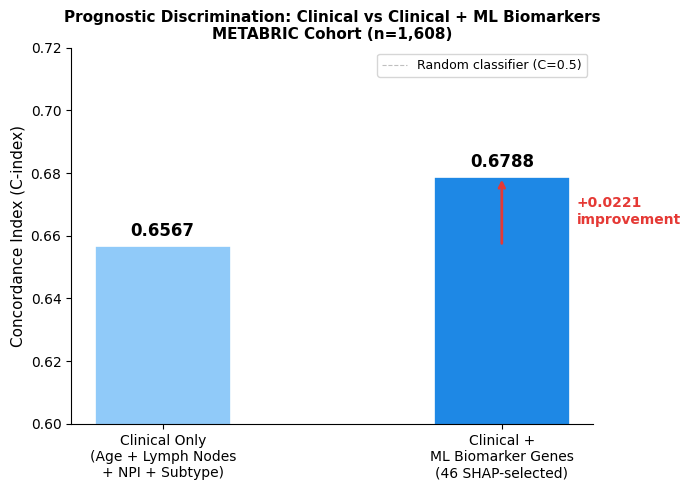

In [15]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Clinical Only\n(Age + Lymph Nodes\n+ NPI + Subtype)",
          "Clinical +\nML Biomarker Genes\n(46 SHAP-selected)"]
cindex = [0.6567, 0.6788]
colors = ["#90CAF9", "#1E88E5"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, cindex, color=colors, width=0.4,
              edgecolor="white", linewidth=1.2)

# Annotate bar values
for bar, val in zip(bars, cindex):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
            f"{val:.4f}", ha="center", va="bottom",
            fontsize=12, fontweight="bold")

# Improvement arrow
ax.annotate("",
    xy=(1, cindex[1]),
    xytext=(1, cindex[0]),
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=2))
ax.text(1.22, (cindex[0] + cindex[1])/2,
        f"+{cindex[1]-cindex[0]:.4f}\nimprovement",
        color="#E53935", fontsize=10, fontweight="bold", va="center")

ax.set_ylim(0.60, 0.72)
ax.set_ylabel("Concordance Index (C-index)", fontsize=11)
ax.set_title(
    "Prognostic Discrimination: Clinical vs Clinical + ML Biomarkers\n"
    "METABRIC Cohort (n=1,608)",
    fontsize=11, fontweight="bold"
)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8,
           alpha=0.5, label="Random classifier (C=0.5)")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("cindex_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
!pip install lifelines --quiet
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

# ── Step 1: Load  ──
merged_clean = pd.read_csv("metabric_survival_analysis.csv")
print("Loaded:", merged_clean.shape)

# ── Step 2: Rebuild gene list ──
biomarker_genes = [
    'ABAT', 'AGR2', 'ASPM', 'AURKA', 'AURKB', 'BTG3', 'BUB1', 'CA12',
    'CACYBP', 'CCNB2', 'CDC6', 'CDCA3', 'CDCA5', 'CENPA', 'CENPE',
    'CEP126', 'CFAP69', 'CMC2', 'EME2', 'ERBB2', 'ESR1', 'EZH2',
    'FOXM1', 'GABRP', 'GATA3', 'GPN1', 'GRB7', 'IL6ST', 'KIF14',
    'LRRC37A2', 'LRRC37A4P', 'MLPH', 'MND1', 'MYBL2', 'NME3',
    'PTTG1', 'SLC35F6', 'SMIM13', 'SPAG5', 'SPDEF', 'SRSF5',
    'STARD10', 'SUV39H2', 'UBE2T', 'WFS1', 'ZNF740'
]
gene_cols = [g for g in biomarker_genes if g in merged_clean.columns]
print(f"Gene columns found: {len(gene_cols)}")

# ── Step 3: Rebuild Cox dataframe ──
cox_df = merged_clean.copy()
cox_df = pd.get_dummies(cox_df, columns=["SUBTYPE"], drop_first=False)

# Drop reference category (Luminal A)
if "SUBTYPE_Luminal A" in cox_df.columns:
    cox_df = cox_df.drop(columns=["SUBTYPE_Luminal A"])

clinical_covariates = [
    "AGE_AT_DIAGNOSIS",
    "LYMPH_NODES_EXAMINED_POSITIVE",
    "NPI",
    "SUBTYPE_Basal",
    "SUBTYPE_Her2",
    "SUBTYPE_Luminal B"
]

# Fill missing lymph nodes
cox_df["LYMPH_NODES_EXAMINED_POSITIVE"] = cox_df[
    "LYMPH_NODES_EXAMINED_POSITIVE"
].fillna(cox_df["LYMPH_NODES_EXAMINED_POSITIVE"].median())

# ── Step 4: Refit Model 2 (Clinical + Genes) ──
cols_full = clinical_covariates + gene_cols + ["OS_MONTHS", "OS_EVENT"]
cph_full = CoxPHFitter(penalizer=0.1)
cph_full.fit(
    cox_df[cols_full],
    duration_col="OS_MONTHS",
    event_col="OS_EVENT"
)
print(f"Model 2 C-index: {cph_full.concordance_index_:.4f}")

# ── Step 5: Proportional Hazards Test (Schoenfeld residuals) ──
print("\n=== PROPORTIONAL HAZARDS TEST (Schoenfeld Residuals) ===")
ph_test = proportional_hazard_test(
    cph_full,
    cox_df[cols_full],
    time_transform='rank'
)
ph_test.print_summary(decimals=4)

# ── Step 6: Flag any violations ──
ph_df = ph_test.summary.copy()
violations = ph_df[ph_df["p"] < 0.05]
print(f"\nVariables violating PH assumption (p < 0.05): {len(violations)}")
if len(violations) > 0:
    print(violations[["test_statistic", "p"]])
else:
    print("None — PH assumption satisfied for all covariates.")

Loaded: (1608, 73)
Gene columns found: 46
Model 2 C-index: 0.6788

=== PROPORTIONAL HAZARDS TEST (Schoenfeld Residuals) ===



Variables violating PH assumption (p < 0.05): 7
                  test_statistic         p
AGE_AT_DIAGNOSIS       15.705332  0.000074
EME2                    7.717393  0.005469
ESR1                    9.745804  0.001797
GABRP                   6.643888  0.009950
IL6ST                   4.821441  0.028108
LRRC37A4P               4.726424  0.029703
NPI                     6.093951  0.013565


In [17]:
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np

# ── Stratify on the two clinical violators (AGE_AT_DIAGNOSIS, NPI) ──
# Create age group and NPI group for stratification
cox_df["AGE_GROUP"] = pd.cut(
    cox_df["AGE_AT_DIAGNOSIS"],
    bins=[0, 50, 60, 70, 120],
    labels=["<50", "50-60", "60-70", ">70"]
).astype(str)

cox_df["NPI_GROUP"] = pd.cut(
    cox_df["NPI"],
    bins=[0, 3.4, 5.4, 20],
    labels=["Good", "Moderate", "Poor"]
).astype(str)

# ── Remove the 5 gene violators from the model ──
violating_genes = ["EME2", "ESR1", "GABRP", "IL6ST", "LRRC37A4P"]
gene_cols_clean = [g for g in gene_cols if g not in violating_genes]
print(f"Genes in sensitivity model: {len(gene_cols_clean)} (removed {len(violating_genes)})")

# ── Build sensitivity model columns ──
# AGE_AT_DIAGNOSIS and NPI are now stratification variables, not covariates
sens_covariates = [
    "LYMPH_NODES_EXAMINED_POSITIVE",
    "SUBTYPE_Basal",
    "SUBTYPE_Her2",
    "SUBTYPE_Luminal B"
]

cols_sensitivity = sens_covariates + gene_cols_clean + ["OS_MONTHS", "OS_EVENT", "AGE_GROUP", "NPI_GROUP"]

# ── Fit stratified Cox model ──
cph_sensitivity = CoxPHFitter(penalizer=0.1)
cph_sensitivity.fit(
    cox_df[cols_sensitivity],
    duration_col="OS_MONTHS",
    event_col="OS_EVENT",
    strata=["AGE_GROUP", "NPI_GROUP"]   # stratify instead of model as covariates
)

print(f"\nSensitivity Model C-index: {cph_sensitivity.concordance_index_:.4f}")
print(f"Main Model C-index:        0.6788")

# ── Check CDCA5 and CMC2 in sensitivity model ──
sens_summary = cph_sensitivity.summary.reset_index()
sens_summary.columns.values[0] = "variable"
key_genes = sens_summary[sens_summary["variable"].isin(["CDCA5", "CMC2"])]
print("\n=== CDCA5 and CMC2 in Sensitivity Model ===")
print(key_genes[["variable", "coef", "exp(coef)", "p"]].to_string())

# ── Verify PH assumption in sensitivity model ──
from lifelines.statistics import proportional_hazard_test
ph_sens = proportional_hazard_test(
    cph_sensitivity,
    cox_df[cols_sensitivity],
    time_transform='rank'
)
ph_sens_df = ph_sens.summary.copy()
remaining_violations = ph_sens_df[ph_sens_df["p"] < 0.05]
print(f"\nRemaining PH violations in sensitivity model: {len(remaining_violations)}")
if len(remaining_violations) > 0:
    print(remaining_violations[["test_statistic", "p"]])

Genes in sensitivity model: 41 (removed 5)

Sensitivity Model C-index: 0.6102
Main Model C-index:        0.6788

=== CDCA5 and CMC2 in Sensitivity Model ===
   variable      coef  exp(coef)         p
16    CDCA5  0.116198   1.123218  0.049499
21     CMC2 -0.087971   0.915788  0.038531

Remaining PH violations in sensitivity model: 0


In [18]:
#Schoenfeld PH test results
ph_test.summary.to_csv("schoenfeld_ph_test_results.csv")
print(ph_test.summary)

                               test_statistic         p   -log2(p)
ABAT                                 2.043045  0.152903   2.709309
AGE_AT_DIAGNOSIS                    15.705332  0.000074  13.721818
AGR2                                 0.216993  0.641341   0.640837
ASPM                                 0.452494  0.501153   0.996676
AURKA                                0.314173  0.575131   0.798038
AURKB                                0.328381  0.566614   0.819562
BTG3                                 0.130123  0.718305   0.477332
BUB1                                 0.327521  0.567123   0.818268
CA12                                 0.085746  0.769656   0.377714
CACYBP                               1.556565  0.212169   2.236715
CCNB2                                0.440878  0.506699   0.980799
CDC6                                 1.130343  0.287702   1.797352
CDCA3                                0.109170  0.741091   0.432276
CDCA5                                2.056314  0.151576   2.72

In [19]:
#CDCA5/CMC2 Cox results
main_results = cph_full.summary.loc[["CDCA5", "CMC2"], ["exp(coef)", "p"]]
main_results.columns = ["Main_HR", "Main_p"]

sens_results = cph_sensitivity.summary.loc[["CDCA5", "CMC2"], ["exp(coef)", "p"]]
sens_results.columns = ["Sens_HR", "Sens_p"]

cox_results = main_results.join(sens_results)
cox_results.to_csv("cdca5_cmc2_cox_results.csv")
print(cox_results)

            Main_HR    Main_p   Sens_HR    Sens_p
covariate                                        
CDCA5      1.143768  0.022631  1.123218  0.049499
CMC2       0.919107  0.049480  0.915788  0.038531


In [20]:
#METABRIC cohort characteristics by subtype
cohort_summary = merged_clean.groupby("SUBTYPE").agg(
    n=("PATIENT_ID", "count"),
    death_events=("OS_EVENT", "sum"),
    median_os_months=("OS_MONTHS", "median"),
    median_age=("AGE_AT_DIAGNOSIS", "median"),
    median_npi=("NPI", "median"),
    lymph_node_positive_pct=("LYMPH_NODES_EXAMINED_POSITIVE", lambda x: (x > 0).mean() * 100),
).round(2)
cohort_summary["death_event_pct"] = (cohort_summary["death_events"] / cohort_summary["n"] * 100).round(1)
cohort_summary.to_csv("metabric_cohort_characteristics.csv")
print(cohort_summary)

             n  death_events  median_os_months  median_age  median_npi  \
SUBTYPE                                                                  
Basal      209           115             85.50       54.22        5.02   
Her2       224           157             97.07       59.06        4.08   
Luminal A  700           378            130.08       63.37        3.08   
Luminal B  475           315            104.10       66.52        4.05   

           lymph_node_positive_pct  death_event_pct  
SUBTYPE                                              
Basal                        51.20             55.0  
Her2                         56.25             70.1  
Luminal A                    41.00             54.0  
Luminal B                    49.89             66.3  


In [21]:
print(df.groupby("SUBTYPE")["OS_EVENT"].agg(["count", "sum"]))

           count    sum
SUBTYPE                
Basal        209  115.0
Her2         224  157.0
Luminal A    700  378.0
Luminal B    475  315.0
